In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [3]:
# f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
# print(f.read())

In [4]:
r_u = 0.25
near_u = 0.75
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2008, 2010)]
years_to_remove = [2008, 2009]
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2008-2019.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,municipality,district,region,municipality_enc,area,pop_1,pop_2,pop_3,pop_total,eq_distance,day,month,week,year,season,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,season_sin,season_cos,mosq_pred,mosq_prev_30d,case_prev_p,case_prev_m,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,hot_days_prev_30d,hot_days_from_newyear,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,case
0,12.02992,45.06869,2010-06-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,6,22,2010,3,0.201299,0.979530,1.224647e-16,-1.000000,4.647232e-01,-0.885456,-1.0,-1.836970e-16,357,2,0,0,0.377443,0.116895,-0.230719,-0.116895,0.378023,0.113023,-0.235218,-0.113023,0.059966,0.04221,0.056778,0.04221,20.778333,29.033333,12.523333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,18.900000,19.233333,440.966667,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
1,12.02992,45.06869,2010-06-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,6,24,2010,3,-0.101168,-0.994869,1.224647e-16,-1.000000,2.393157e-01,-0.970942,-1.0,-1.836970e-16,310,358,0,0,0.377443,0.116895,-0.230719,-0.116895,0.378023,0.113023,-0.235218,-0.113023,0.059966,0.04221,0.056778,0.04221,24.920000,31.536667,18.303333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,53.033333,59.100000,500.066667,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
2,12.02992,45.06869,2010-07-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,7,26,2010,3,0.201299,0.979530,-5.000000e-01,-0.866025,-3.216245e-16,-1.000000,-1.0,-1.836970e-16,654,667,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.861667,29.756667,17.966667,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,2.800000,76.133333,576.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
3,12.02992,45.06869,2010-07-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,7,28,2010,3,-0.101168,-0.994869,-5.000000e-01,-0.866025,-2.393157e-01,-0.970942,-1.0,-1.836970e-16,301,964,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.560000,35.130000,23.990000,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,0.600000,52.033333,628.233333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
4,12.02992,45.06869,2010-08-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,8,30,2010,3,0.201299,0.979530,-8.660254e-01,-0.500000,-4.647232e-01,-0.885456,-1.0,-1.836970e-16,400,955,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.665000,32.036667,17.293333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,3.900000,10.966667,639.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0


In [6]:
# dataset = dataset.query('month >= 6 & month <= 10')
# dataset.reset_index(inplace=True, drop=True)

dataset.rename(columns={"municipality": "lau1", "district": "nuts3", "region" : "nuts2", "municipality_enc" : "lau1_id"}, inplace=True)

In [7]:
dataset

,x,y,dt_placement,lau1,nuts3,nuts2,lau1_id,area,pop_1,pop_2,pop_3,pop_total,eq_distance,day,month,week,year,season,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,season_sin,season_cos,mosq_pred,mosq_prev_30d,case_prev_p,case_prev_m,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,hot_days_prev_30d,hot_days_from_newyear,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,case
0,12.02992,45.06869,2010-06-01,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,1,6,22,2010,3,0.201299,0.979530,1.224647e-16,-1.000000,4.647232e-01,-0.885456,-1.0,-1.836970e-16,357,2,0,0,0.377443,0.116895,-0.230719,-0.116895,0.378023,0.113023,-0.235218,-0.113023,0.059966,0.042210,0.056778,0.042210,20.778333,29.033333,12.523333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,18.900000,19.233333,440.966667,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
1,12.02992,45.06869,2010-06-16,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,16,6,24,2010,3,-0.101168,-0.994869,1.224647e-16,-1.000000,2.393157e-01,-0.970942,-1.0,-1.836970e-16,310,358,0,0,0.377443,0.116895,-0.230719,-0.116895,0.378023,0.113023,-0.235218,-0.113023,0.059966,0.042210,0.056778,0.042210,24.920000,31.536667,18.303333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,53.033333,59.100000,500.066667,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
2,12.02992,45.06869,2010-07-01,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,1,7,26,2010,3,0.201299,0.979530,-5.000000e-01,-0.866025,-3.216245e-16,-1.000000,-1.0,-1.836970e-16,654,667,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.861667,29.756667,17.966667,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,2.800000,76.133333,576.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
3,12.02992,45.06869,2010-07-16,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,16,7,28,2010,3,-0.101168,-0.994869,-5.000000e-01,-0.866025,-2.393157e-01,-0.970942,-1.0,-1.836970e-16,301,964,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.560000,35.130000,23.990000,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,0.600000,52.033333,628.233333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
4,12.02992,45.06869,2010-08-01,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,1,8,30,2010,3,0.201299,0.979530,-8.660254e-01,-0.500000,-4.647232e-01,-0.885456,-1.0,-1.836970e-16,400,955,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.665000,32.036667,17.293333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,3.900000,10.966667,639.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,11.87360,45.40709,2018-08-16,padova,padova,veneto,86,92.983675,523.139,486.379,130.112,1139.63,46.93385,16,8,33,2018,3,-0.101168,-0.994869,-8.660254e-01,-0.500000,-7.485107e-01,-0.663123,-1.0,-1.836970e-16,27,260,1,1,0.554525,0.210431,-0.480996,-0.210431,0.495450,0.152821,-0.434756,-0.152821,0.104371,0.075031,0.078626,0.075031,27.130000,32.910000,21.350000,7.969862,0.685386,7.575429,-2.387659,15.673011,2.14352,26.639646,11.963797,1,1,48.833333,56.233333,546.200000,8095.541103,2727.375817,17,133.559342,17.254

In [8]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,1901,7,1908,9.99%
1,2011,1897,11,1908,9.99%
2,2012,1877,34,1911,10.00%
3,2013,1880,29,1909,9.99%
4,2014,1906,2,1908,9.99%
5,2015,1907,1,1908,9.99%
6,2016,1896,12,1908,9.99%
7,2017,1892,17,1909,9.99%
8,2018,1791,134,1925,10.08%
9,2019,1873,37,1910,10.00%


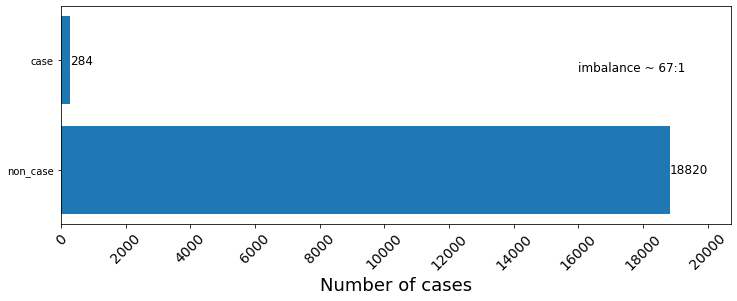

In [9]:
plot_imbalance(dataset)

In [10]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [11]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:8 || ##
Year: 2011 || w0:1, w1:8 || ##
Year: 2012 || w0:1, w1:9 || ##
Year: 2013 || w0:1, w1:9 || ##
Year: 2014 || w0:1, w1:8 || ##
Year: 2015 || w0:1, w1:8 || ##
Year: 2016 || w0:1, w1:8 || ##
Year: 2017 || w0:1, w1:8 || ##
Year: 2018 || w0:1, w1:14 || ##
Year: 2019 || w0:1, w1:9 || ##


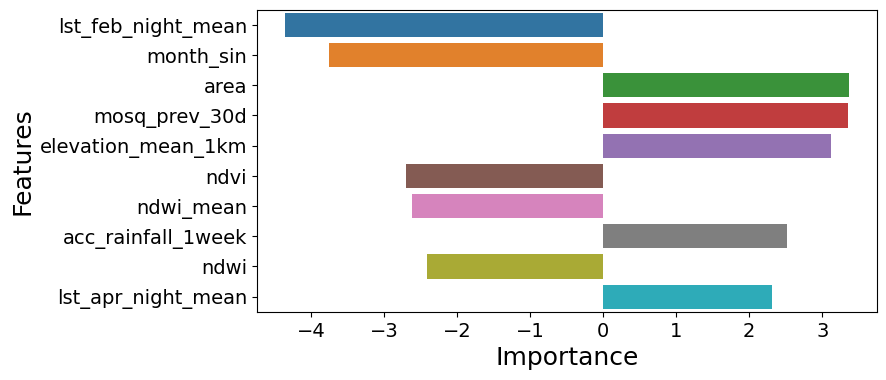

In [12]:
plot_feature_importance(coefficients, feature_names, top = 10, figure_size = (8, 4))

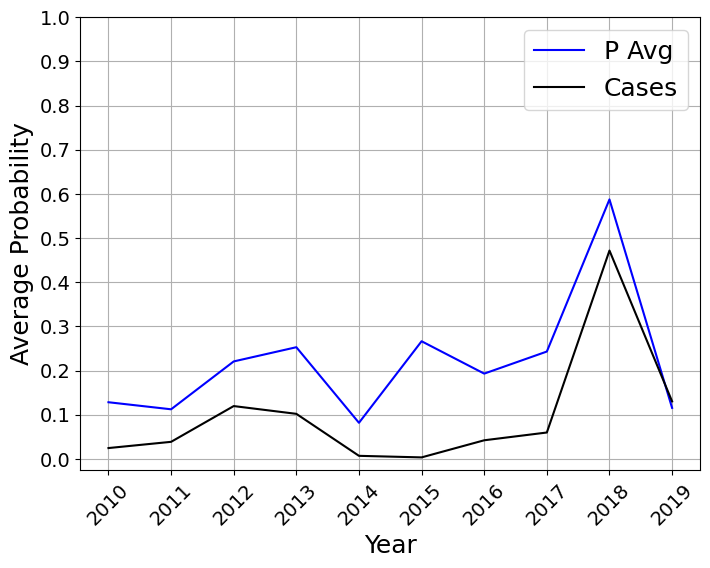

In [13]:
plot_trend_curve(results_test, list(dsc['case']))

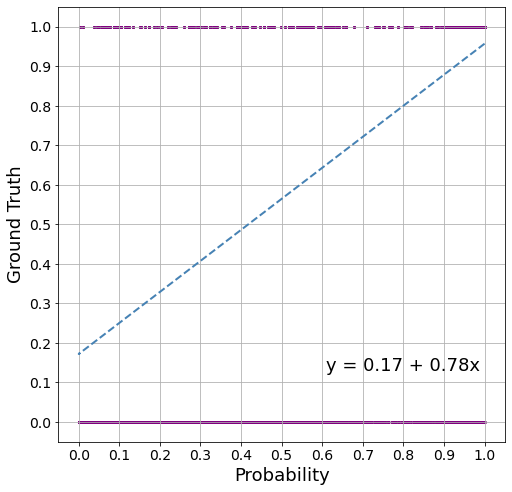

In [14]:
plot_probability_curve(results_test)

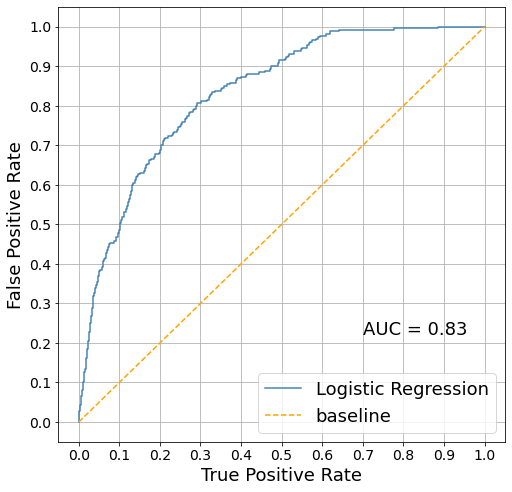

In [15]:
plot_roc_curve(results_test)

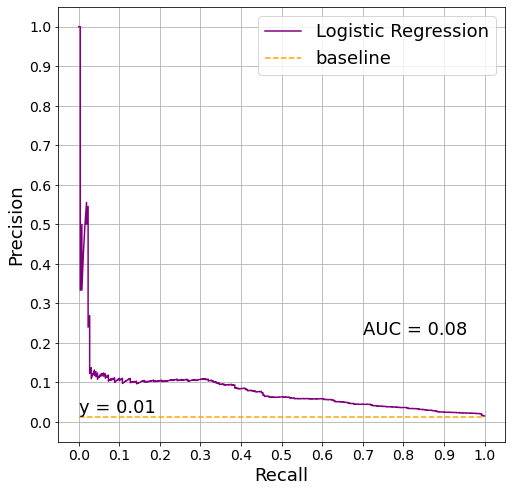

In [16]:
plot_pr_curve(results_test)

In [17]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 10, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 14.72%
Weighted Average: 18.91%


In [18]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2010,0,0,0,NaN,NaN
1,16/06/2010,0,0,0,NaN,NaN
2,01/07/2010,1,0,1,0.00 %,0.0
3,16/07/2010,0,0,0,NaN,NaN
4,01/08/2010,0,0,0,NaN,NaN
...,...,...,...,...,...,...
115,16/09/2019,5,0,5,0.00 %,0.0
116,01/10/2019,1,0,1,0.00 %,0.0
117,16/10/2019,0,0,0,NaN,NaN
118,01/11/2019,0,0,0,NaN,NaN


In [19]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,7,3,7,42.86 %,0.4286
1,2011,11,2,11,18.18 %,0.1818
2,2012,31,8,29,27.59 %,0.2759
3,2013,28,3,25,12.00 %,0.1200
4,2014,2,0,2,0.00 %,0.0000
5,2015,1,0,1,0.00 %,0.0000
6,2016,12,1,12,8.33 %,0.0833
7,2017,16,1,16,6.25 %,0.0625
8,2018,117,13,56,23.21 %,0.2321
9,2019,35,3,34,8.82 %,0.0882


In [20]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.23, beta = 4)

In [21]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,7.0,0.1986,0.6871,0.0106,0.5714,0.1385,0.1980
1,2011,11.0,0.1295,0.6178,0.0162,0.3636,0.1608,0.1891
2,2012,31.0,0.3705,0.7871,0.0410,0.9355,0.4098,0.3399
3,2013,28.0,0.4544,0.7769,0.0323,1.0000,0.3620,0.4148
4,2014,2.0,0.0797,0.7104,0.0066,0.5000,0.0924,0.1297
5,2015,1.0,0.4444,0.7779,0.0012,1.0000,0.0197,0.4615
6,2016,12.0,0.3333,0.7935,0.0173,0.9167,0.2258,0.3236
7,2017,16.0,0.4151,0.7634,0.0189,0.9375,0.2433,0.4108
8,2018,117.0,0.7537,0.6221,0.0800,0.9829,0.5906,1.5638
9,2019,35.0,0.1619,0.5339,0.0259,0.2286,0.1565,0.2078


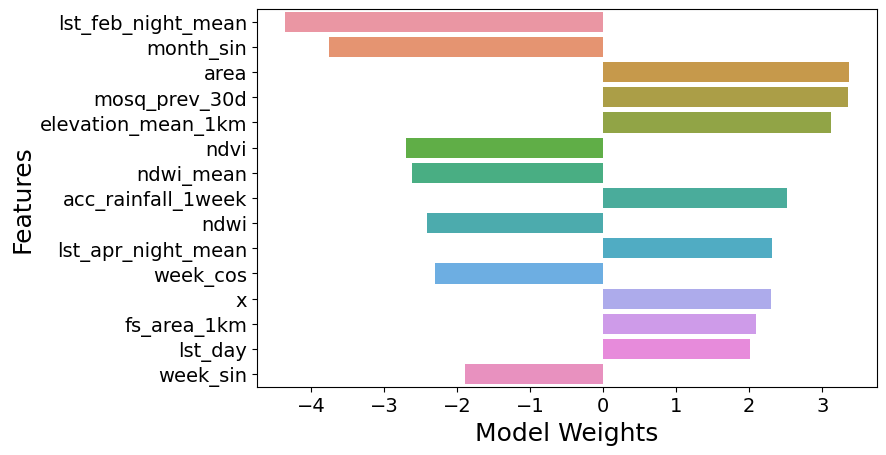

In [26]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))